In [1]:
!pip install -q keras-nlp matplotlib

In [2]:
import pandas as pd
import keras_nlp
import tensorflow as tf
import matplotlib.pyplot as plt
import random
from sklearn.model_selection import train_test_split
from tensorflow import keras

In [3]:
# Load the fine-tuned model
gpt2_lm = keras.models.load_model("/kaggle/input/gpt2_dialog_v1/keras/default/1/fine_tuned_gpt2_dialog.keras", compile=False)

# (Re)compile with same or new optimizer
gpt2_lm.compile(optimizer=keras.optimizers.Adam(learning_rate=5e-5))

/usr/local/lib/python3.10/dist-packages/keras/src/saving/saving_lib.py:713: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 394 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [4]:
# Load dataset
df = pd.read_feather("/kaggle/input/diagnoise-me/diagnose_en_dataset.feather").iloc[15000:30000]
print(df[["Patient", "Doctor"]].head())

# Combine question and answer into dialogue format
df["text"] = df.apply(lambda row: f"Patient: {row['Patient']}\nDoctor: {row['Doctor']}", axis=1)

                                                 Patient  \
15000  Hello doctor, My fiancee and I had unprotected...   
15001  Hello doctor, My friend aged 30 had two drops ...   
15002  Hello doctor,As I have PCOD problem and also c...   
15003  Hi doctor, I had sex for the first time. After...   
15004  Hello doctor, I am a patient of oral fibrosis....   

                                                  Doctor  
15000  Hi. How are you doing? Yes, as you have heard,...  
15001  Hi. I want to assure you not to worry as every...  
15002  Hello. For PCOD (polycystic ovarian disease), ...  
15003  Hello. As the serum beta hCG levels are less t...  
15004  Hello. Oral submucous fibrosis is a common pre...  


In [5]:
# Split the dataset into training and validation sets
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)
print(f"Train size: {train_df.shape}")
print(f"Validation size: {val_df.shape}")

batch_size = 2
train_ds = tf.data.Dataset.from_tensor_slices(train_df["text"].values)
train_ds = train_ds.shuffle(buffer_size=len(train_df)).batch(batch_size)

val_ds = tf.data.Dataset.from_tensor_slices(val_df["text"].values)
val_ds = val_ds.shuffle(buffer_size=len(val_df)).batch(batch_size)

Train size: (12000, 5)
Validation size: (3000, 5)


In [6]:
history = gpt2_lm.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 4593s 754ms/step - loss: 0.4009 - sparse_categorical_accuracy: 0.6885 - val_loss: 0.3790 - val_sparse_categorical_accuracy: 0.7081
Epoch 2/5
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 4528s 755ms/step - loss: 0.3610 - sparse_categorical_accuracy: 0.7114 - val_loss: 0.3779 - val_sparse_categorical_accuracy: 0.7094
Epoch 3/5
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 4529s 755ms/step - loss: 0.3369 - sparse_categorical_accuracy: 0.7246 - val_loss: 0.3782 - val_sparse_categorical_accuracy: 0.7097
Epoch 4/5
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 4532s 755ms/step - loss: 0.3189 - sparse_categorical_accuracy: 0.7337 - val_loss: 0.3822 - val_sparse_categorical_accuracy: 0.7088
Epoch 5/5
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 4530s 755ms/step - loss: 0.2984 - sparse_categorical_accuracy: 0.7421 - val_loss: 0.3890 - val_sparse_categorical_accuracy: 0.7079


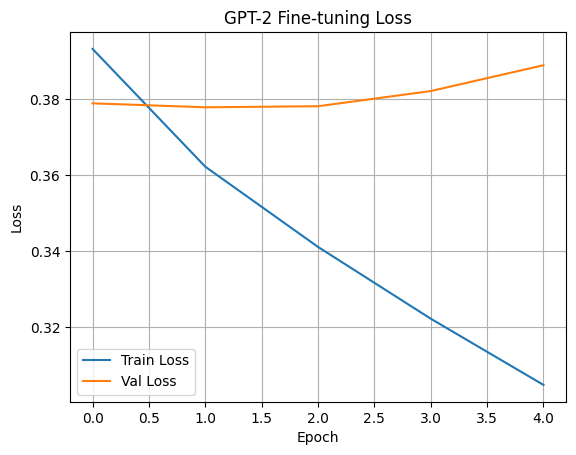

In [7]:
# Save fine-tuned model
gpt2_lm.save("/kaggle/working/fine_tuned_gpt2_dialog_v2.keras")

# Plot training loss
plt.plot(history.history["loss"], label="Train Loss")
if "val_loss" in history.history:
    plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("GPT-2 Fine-tuning Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.savefig("training_loss_plot.png")
plt.show()

In [8]:
# Create a list to hold test results
results = []

# Generate and collect answers for 10 random questions
sample_df = df.sample(10, random_state=42)[["Patient", "Doctor"]]

for i, row in sample_df.iterrows():
    question = row["Patient"]
    true_answer = row["Doctor"]
    prompt = f"Patient: {question}\nDoctor:"
    
    # Generate model response
    generated = gpt2_lm.generate(prompt, max_length=100)
    
    # Save to results
    results.append({
        "question": question,
        "true_answer": true_answer,
        "generated_answer": generated
    })

# Save results to a DataFrame and then to CSV
results_df = pd.DataFrame(results)
results_df.to_csv("/kaggle/working/test_results.csv", index=False)
print("✅ Saved test results to /kaggle/working/test_results.csv")

✅ Saved test results to /kaggle/working/test_results.csv
